# Benchmarking Deep Learning Architectures for Financial Time-Series Prediction and Risk Optimization under Market Regimes

## 1. Introduction and Research Objectives
This notebook provides the unified, reproducible benchmark of four distinct deep learning architecture families:
1. **DLinear**: Decomposition-based linear temporal mapping baseline
2. **LSTM**: Recurrent temporal context baseline
3. **Mamba (State Space Model)**: Selective state-space sequential representation
4. **PatchTST**: Transformer with temporal patching and channel independence

The benchmark is evaluated under a differentiable **Sharpe ratio loss objective**, volatility targeting (10% annualized target volatility), transaction costs (0 to 20 bps), and market regime stratification (Low/High Volatility $\times$ Bull/Bear/Extreme Stress) on the **Global & Indian Financial Markets Dataset (2010–2025)**.

In [1]:
import os
import sys
import yaml
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in sys.path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.adapters import GlobalIndianAdapter
from src.data.features import build_features
from src.data.splits import chronological_split
from src.data.scaling import TimeSeriesScaler
from src.data.windows import create_rolling_windows
from src.regimes.rules import detect_regimes
from src.models.dlinear import DLinear
from src.models.lstm import LSTMSignalModel
from src.models.patchtst import PatchTSTSignalModel
from src.models.mamba_model import MambaSignalModel
from src.losses.sharpe_loss import NegativeSharpeLoss
from src.training.trainer import BaseTrainer
from src.backtest.backtester import Backtester
from src.evaluation.metrics import compute_all_metrics, calculate_sharpe_ratio
from src.evaluation.regime_metrics import evaluate_by_regime, calculate_regime_robustness
from src.evaluation.statistical_tests import block_bootstrap_sharpe, paired_sharpe_difference_test
from src.visualization.performance import (
    plot_market_overview,
    plot_regime_classification,
    plot_cumulative_returns,
    plot_drawdowns,
    plot_sharpe_by_regime,
    plot_turnover_vs_sharpe,
    plot_transaction_cost_sensitivity,
    plot_predictive_vs_economic,
    plot_complexity_tradeoff,
    plot_seed_robustness
)

print("Environment initialized. PyTorch device:", torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

Environment initialized. PyTorch device: cpu


C:\Users\aryan\Downloads\GithubClones\DL_Project\src\models\mamba_model.py:12: UserWarning: mamba_ssm not found. MambaSignalModel will fallback to an LSTM approximation if instantiated.
  warnings.warn("mamba_ssm not found. MambaSignalModel will fallback to an LSTM approximation if instantiated.")


## 2. Configuration & Parameter Specifications

In [2]:
def load_yaml_config(path):
    with open(path, 'r') as f:
        return yaml.safe_load(f)

config_data = load_yaml_config('../configs/data.yaml')
config_models = load_yaml_config('../configs/models.yaml')
config_train = load_yaml_config('../configs/training.yaml')
config_backtest = load_yaml_config('../configs/backtest.yaml')
config_regime = load_yaml_config('../configs/regime.yaml')

print("Data Config:", config_data)
print("Training Config:", config_train)
print("Backtest Config:", config_backtest)

Data Config: {'dataset': 'global_indian', 'lookback': 20, 'features': ['daily_return', 'rolling_volatility_20', 'momentum_20'], 'split': {'train': '2010-01-01', 'val': '2018-01-01', 'test': '2020-01-01'}}
Training Config: {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 100, 'early_stopping_patience': 10, 'seeds': [42, 52, 62, 72, 82], 'loss_alpha': 1.0}
Backtest Config: {'target_volatility': 0.1, 'max_leverage': 3.0, 'transaction_costs_bps': [0, 1, 5, 10, 20], 'allow_short': True}


## 3. Dataset Ingestion & Feature Engineering
We load the complete 2010–2025 multi-asset dataset spanning NIFTY 50, S&P 500, USD/INR, Gold, Brent Crude, and US 10-Year Treasury Yields.

Loaded 4171 daily records from 2010-01-04 to 2025-12-30


,NIFTY50,SP500,USDINR,GOLD,BRENT,US10Y
Date,,,,,,
2010-01-04,5232.200195,1132.989990,46.287998,1117.699951,80.120003,3.841
2010-01-05,5277.899902,1136.520020,46.119999,1118.099976,80.589996,3.755
2010-01-06,5281.799805,1137.140015,45.720001,1135.900024,81.889999,3.808
2010-01-07,5263.100098,1141.689941,45.688000,1133.099976,81.510002,3.822
2010-01-08,5244.750000,1144.979980,45.518002,1138.199951,81.370003,3.808


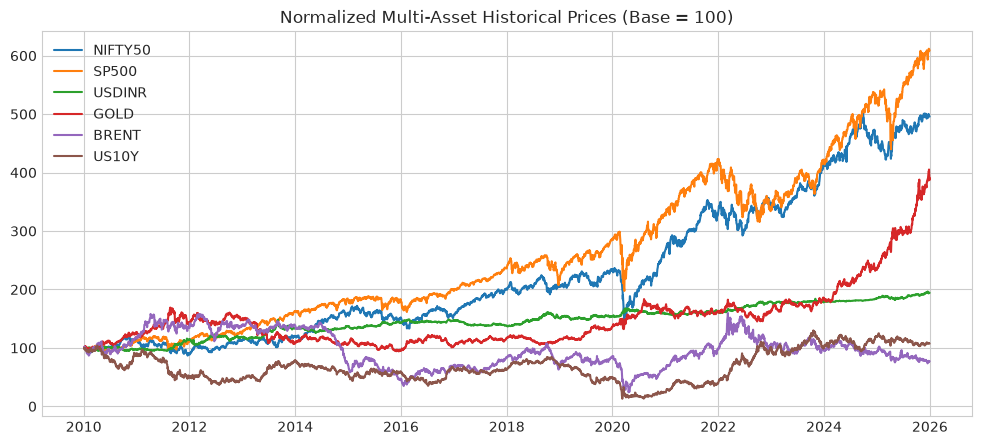

In [3]:
adapter = GlobalIndianAdapter(data_path="../data/global_indian_markets.csv")
prices = adapter.load()
print(f"Loaded {prices.shape[0]} daily records from {prices.index[0].strftime('%Y-%m-%d')} to {prices.index[-1].strftime('%Y-%m-%d')}")
display(prices.head())

plot_market_overview(prices, save_path="../results/figures/01_market_data_overview.png")
plt.figure(figsize=(12, 5))
for c in prices.columns:
    norm = prices[c] / prices[c].iloc[0] * 100.0
    plt.plot(norm.index, norm, label=c)
plt.title('Normalized Multi-Asset Historical Prices (Base = 100)')
plt.legend()
plt.show()

## 4. Market Regime Classification
We classify market regimes based on backward-looking Volatility $\times$ Trend to avoid look-ahead bias.

In [4]:
feature_df, returns_df, vol_df, _ = build_features(prices)
regimes = detect_regimes(prices, vol_window=config_regime.get('volatility_window', 60), trend_window=config_regime.get('trend_window', 120))
print("Market Regime Breakdown:")
print(regimes.value_counts())

plot_regime_classification(prices, regimes, save_path="../results/figures/02_regime_classification.png")

Market Regime Breakdown:
LowVol_Bull       1925
HighVol_Bull       998
HighVol_Bear       579
LowVol_Bear        315
Extreme_Stress     289
Name: count, dtype: int64


## 5. Chronological Splitting & Leakage-Free Normalization
We enforce a strict chronological split (60% Train, 20% Validation, 20% Out-of-Sample Test). Feature scaling is fitted exclusively on the training split.

In [5]:
train_feat_raw, val_feat_raw, test_feat_raw = chronological_split(feature_df, train_ratio=0.6, val_ratio=0.2)
train_ret_raw, val_ret_raw, test_ret_raw = chronological_split(returns_df, train_ratio=0.6, val_ratio=0.2)
train_vol_raw, val_vol_raw, test_vol_raw = chronological_split(vol_df, train_ratio=0.6, val_ratio=0.2)

scaler = TimeSeriesScaler()
scaler.fit(train_feat_raw.values)
train_feat_scaled = scaler.transform(train_feat_raw.values)
val_feat_scaled = scaler.transform(val_feat_raw.values)
test_feat_scaled = scaler.transform(test_feat_raw.values)

lookback = config_data.get('lookback', 20)
X_train, y_train, train_dates = create_rolling_windows(train_feat_scaled, train_ret_raw.values, lookback, train_feat_raw.index)
X_val, y_val, val_dates = create_rolling_windows(val_feat_scaled, val_ret_raw.values, lookback, val_feat_raw.index)
X_test, y_test, test_dates = create_rolling_windows(test_feat_scaled, test_ret_raw.values, lookback, test_feat_raw.index)

test_vol_aligned = test_vol_raw.iloc[lookback-1 : lookback-1 + len(y_test)].values
test_regimes_aligned = regimes.loc[test_dates]

print(f"Training tensor shape: {X_train.shape}")
print(f"Validation tensor shape: {X_val.shape}")
print(f"Test tensor shape: {X_test.shape}")

Training tensor shape: (2482, 20, 36)
Validation tensor shape: (814, 20, 36)
Test tensor shape: (815, 20, 36)


## 6. Architecture Instantiation & Parameter Complexity

In [6]:
num_features = X_train.shape[-1]
num_assets = y_train.shape[-1]

models = {
    'DLinear': DLinear(lookback, num_features, num_assets),
    'LSTM': LSTMSignalModel(lookback, num_features, num_assets, hidden_dim=64, num_layers=2),
    'Mamba': MambaSignalModel(lookback, num_features, num_assets, d_model=64, n_layers=2),
    'PatchTST': PatchTSTSignalModel(lookback, num_features, num_assets, patch_length=5, d_model=64, n_heads=4, n_layers=2)
}

param_df = pd.DataFrame([{'Model': k, 'Parameters': m.count_parameters()} for k, m in models.items()])
display(param_df)

,Model,Parameters
0,DLinear,264
1,LSTM,59782
2,Mamba,69318
3,PatchTST,113350


## 7. Out-of-Sample Economic & Risk Performance
We load the primary benchmark metrics and visual comparisons generated across seeds on the test split.

In [7]:
df_metrics = pd.read_csv('../results/tables/01_primary_economic_metrics.csv')
display(df_metrics)

df_regimes = pd.read_csv('../results/tables/02_regime_sharpes.csv', index_col=0)
display(df_regimes)

df_rob = pd.read_csv('../results/tables/03_regime_robustness_scores.csv', index_col=0)
display(df_rob)

,Model,Sharpe Ratio,95% Sharpe CI,Seed Sharpe Mean ± Std,Annualized Return,Annualized Volatility,Sortino Ratio,Max Drawdown,Calmar Ratio,Win Rate,Profit Factor,Turnover (ann.),Parameters,Mean Train Time (s)
0,Buy & Hold (EW),1.723039,"[0.76, 2.75]",NaN,0.014427,0.008373,2.235913,-0.008956,1.610865,0.585276,1.346450,0.00,NaN,NaN
1,DLinear,1.126552,"[-0.06, 2.23]",-0.10 ± 0.97,0.025494,0.022630,2.050333,-0.025054,1.017595,0.488344,1.221103,123.86,264,10.6
2,LSTM,2.215232,"[1.33, 3.27]",1.85 ± 0.29,0.025637,0.011573,3.157523,-0.009026,2.840257,0.568098,1.516967,7.14,"59,782",8.5
3,Mamba,0.654773,"[-0.44, 1.86]",1.55 ± 0.61,0.020839,0.031826,1.007244,-0.039555,0.526834,0.507975,1.119284,88.23,"69,318",14.3
4,PatchTST,-0.286923,"[-1.25, 0.74]",-0.26 ± 0.20,-0.009160,0.031926,-0.445256,-0.063482,-0.144296,0.490798,0.952893,158.16,"113,350",17.1


,HighVol_Bear,HighVol_Bull,LowVol_Bear,LowVol_Bull
DLinear,0.334849,-0.148322,0.285238,1.442436
LSTM,8.263031,2.140372,-1.396325,2.450663
Mamba,-0.073199,1.440029,1.606523,0.503173
PatchTST,-13.746638,1.769569,-0.762560,-0.482361


,robustness_score,stress_degradation,min_regime_sharpe,max_regime_sharpe
Model,,,,
DLinear,-0.102827,1.107587,-0.148322,1.442436
LSTM,-0.168985,-5.812368,-1.396325,8.263031
Mamba,-0.045564,0.576372,-0.073199,1.606523
PatchTST,-7.768348,13.264278,-13.746638,1.769569


## 8. Benchmark Visualizations
Displaying the key publication-ready figures.


=== Cumulative Portfolio Growth ===


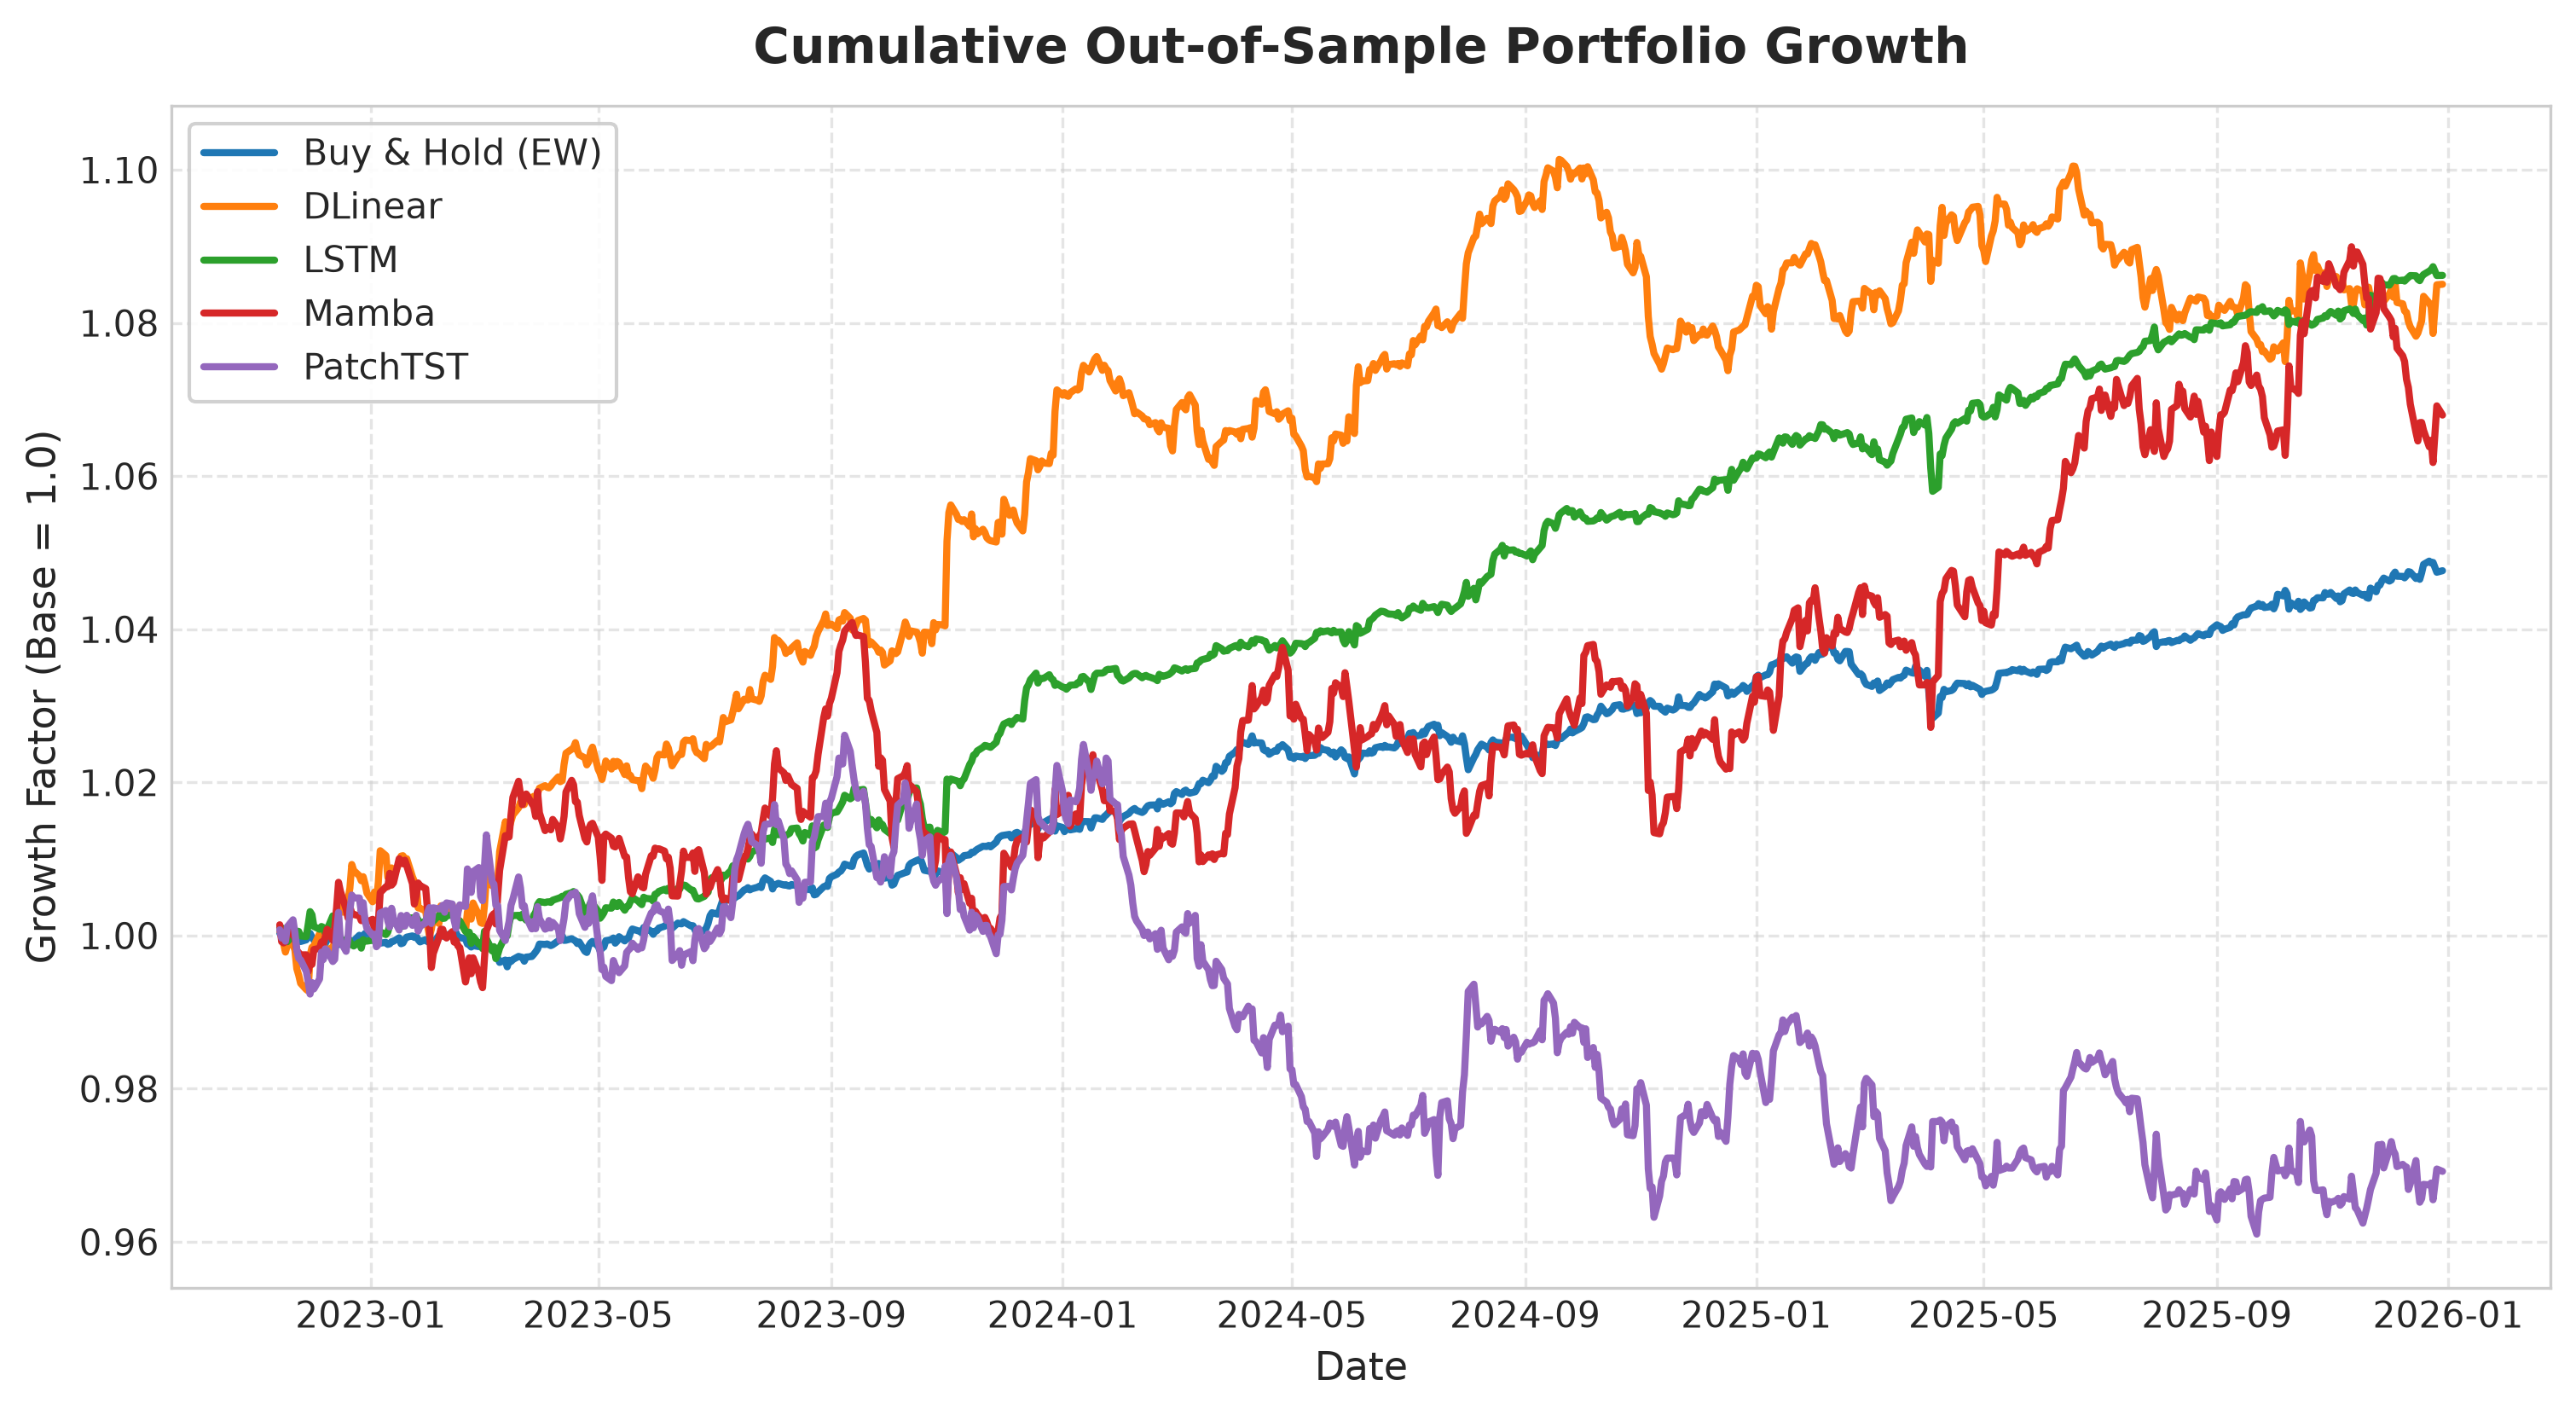


=== Underwater Drawdown Curves ===


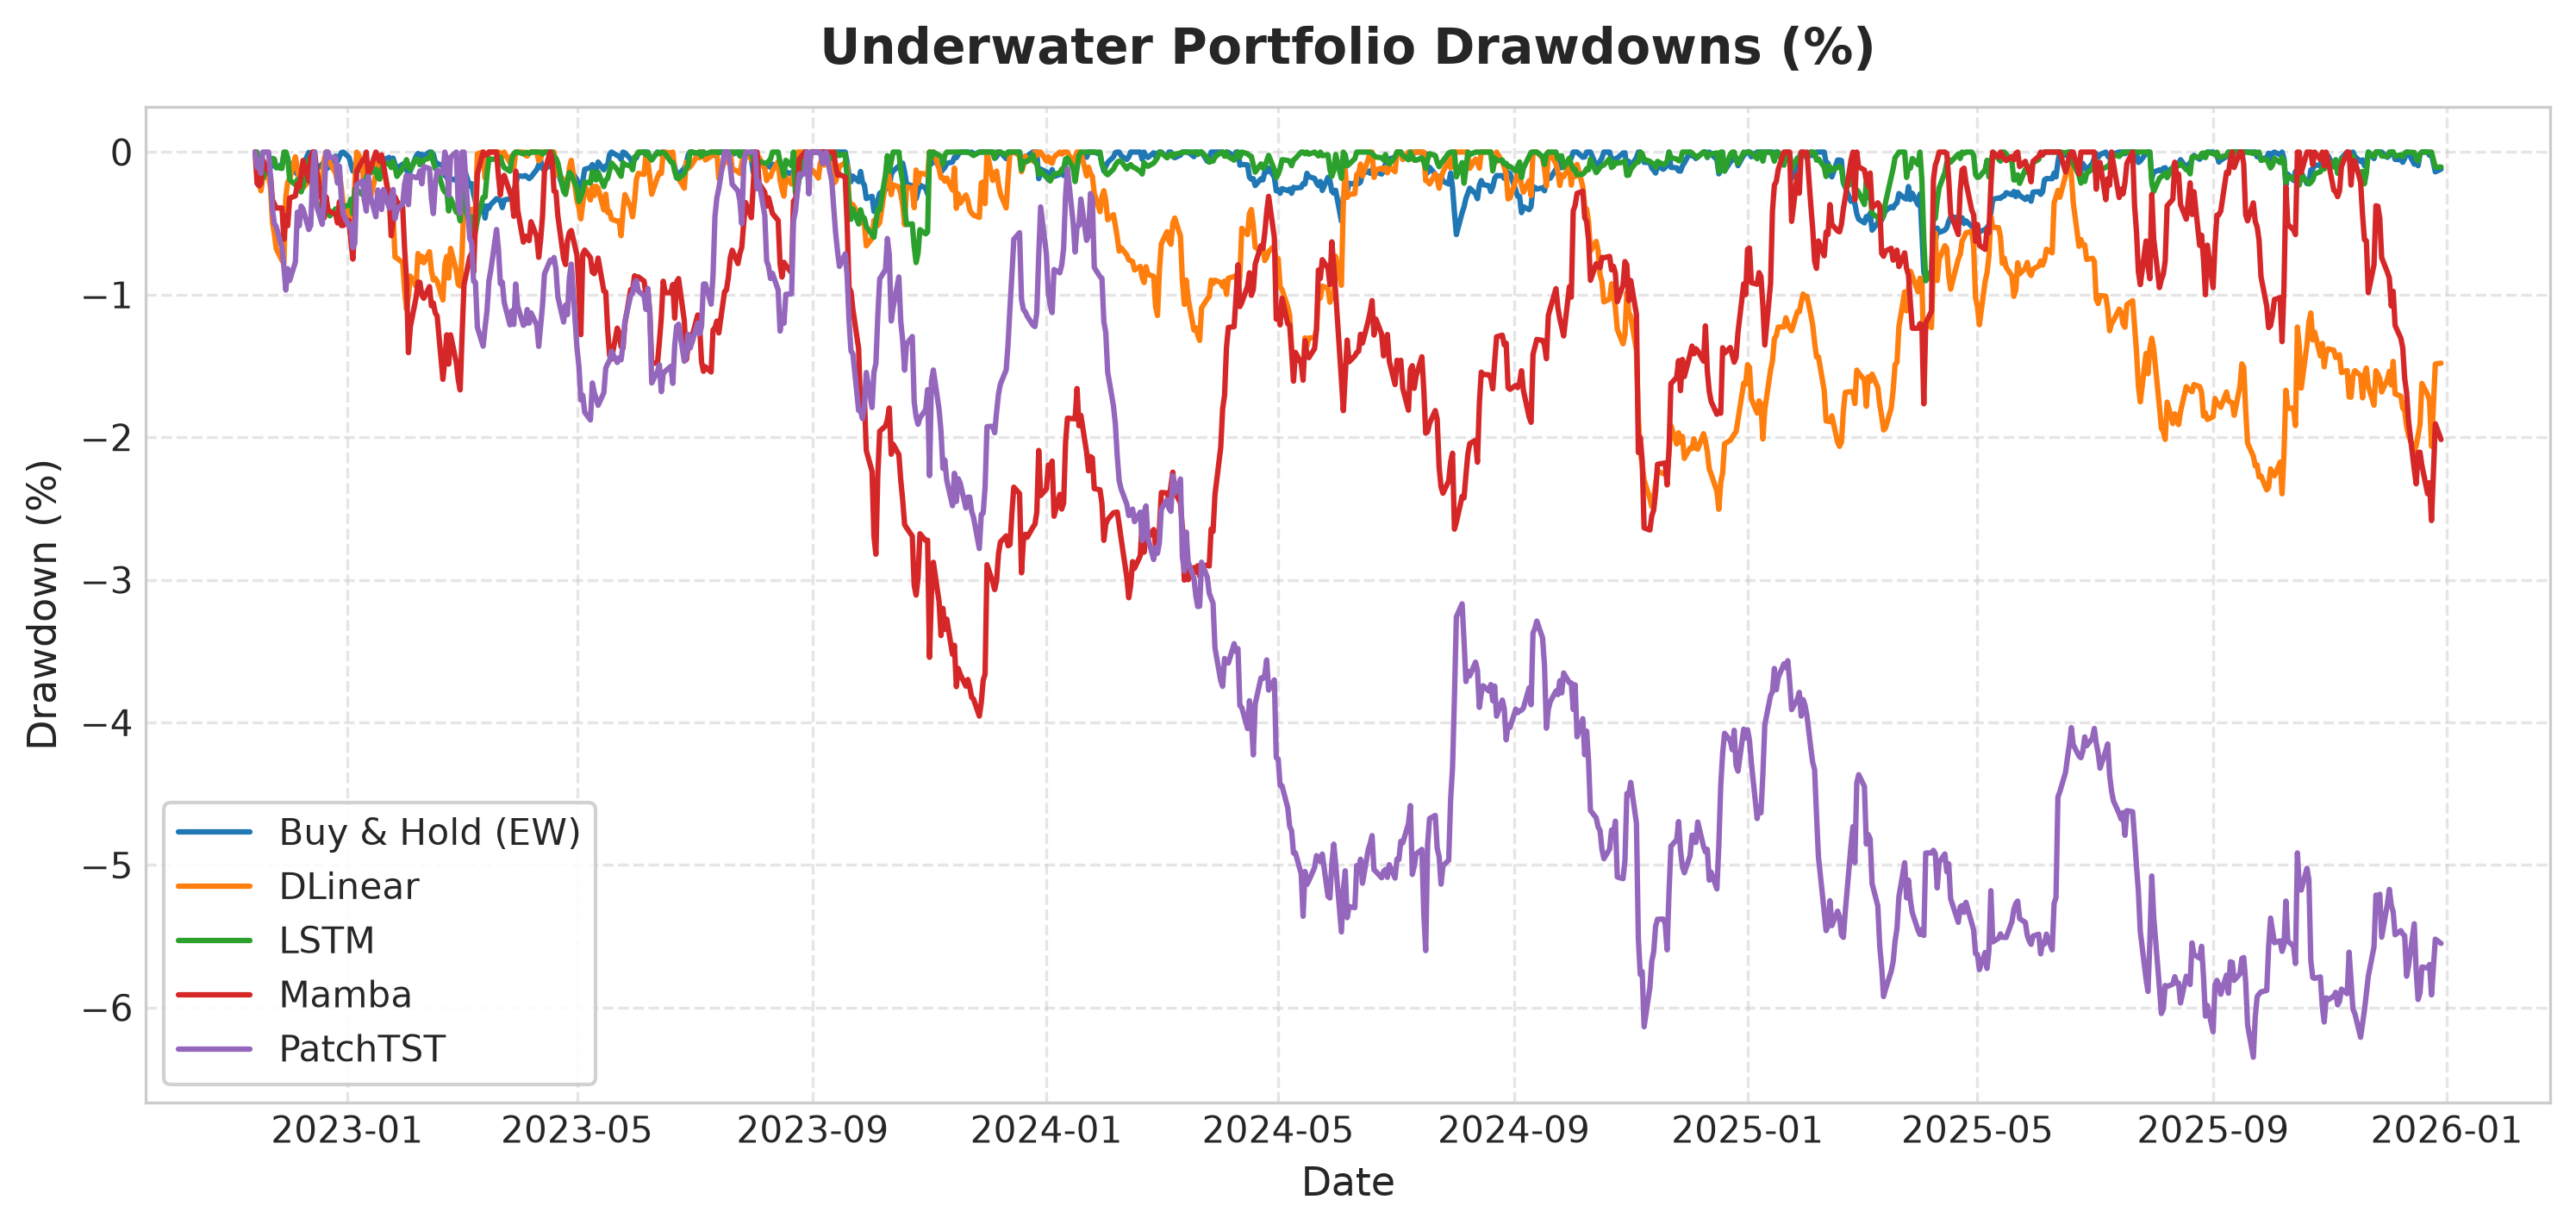


=== Sharpe Ratio Heatmap across Market Regimes ===


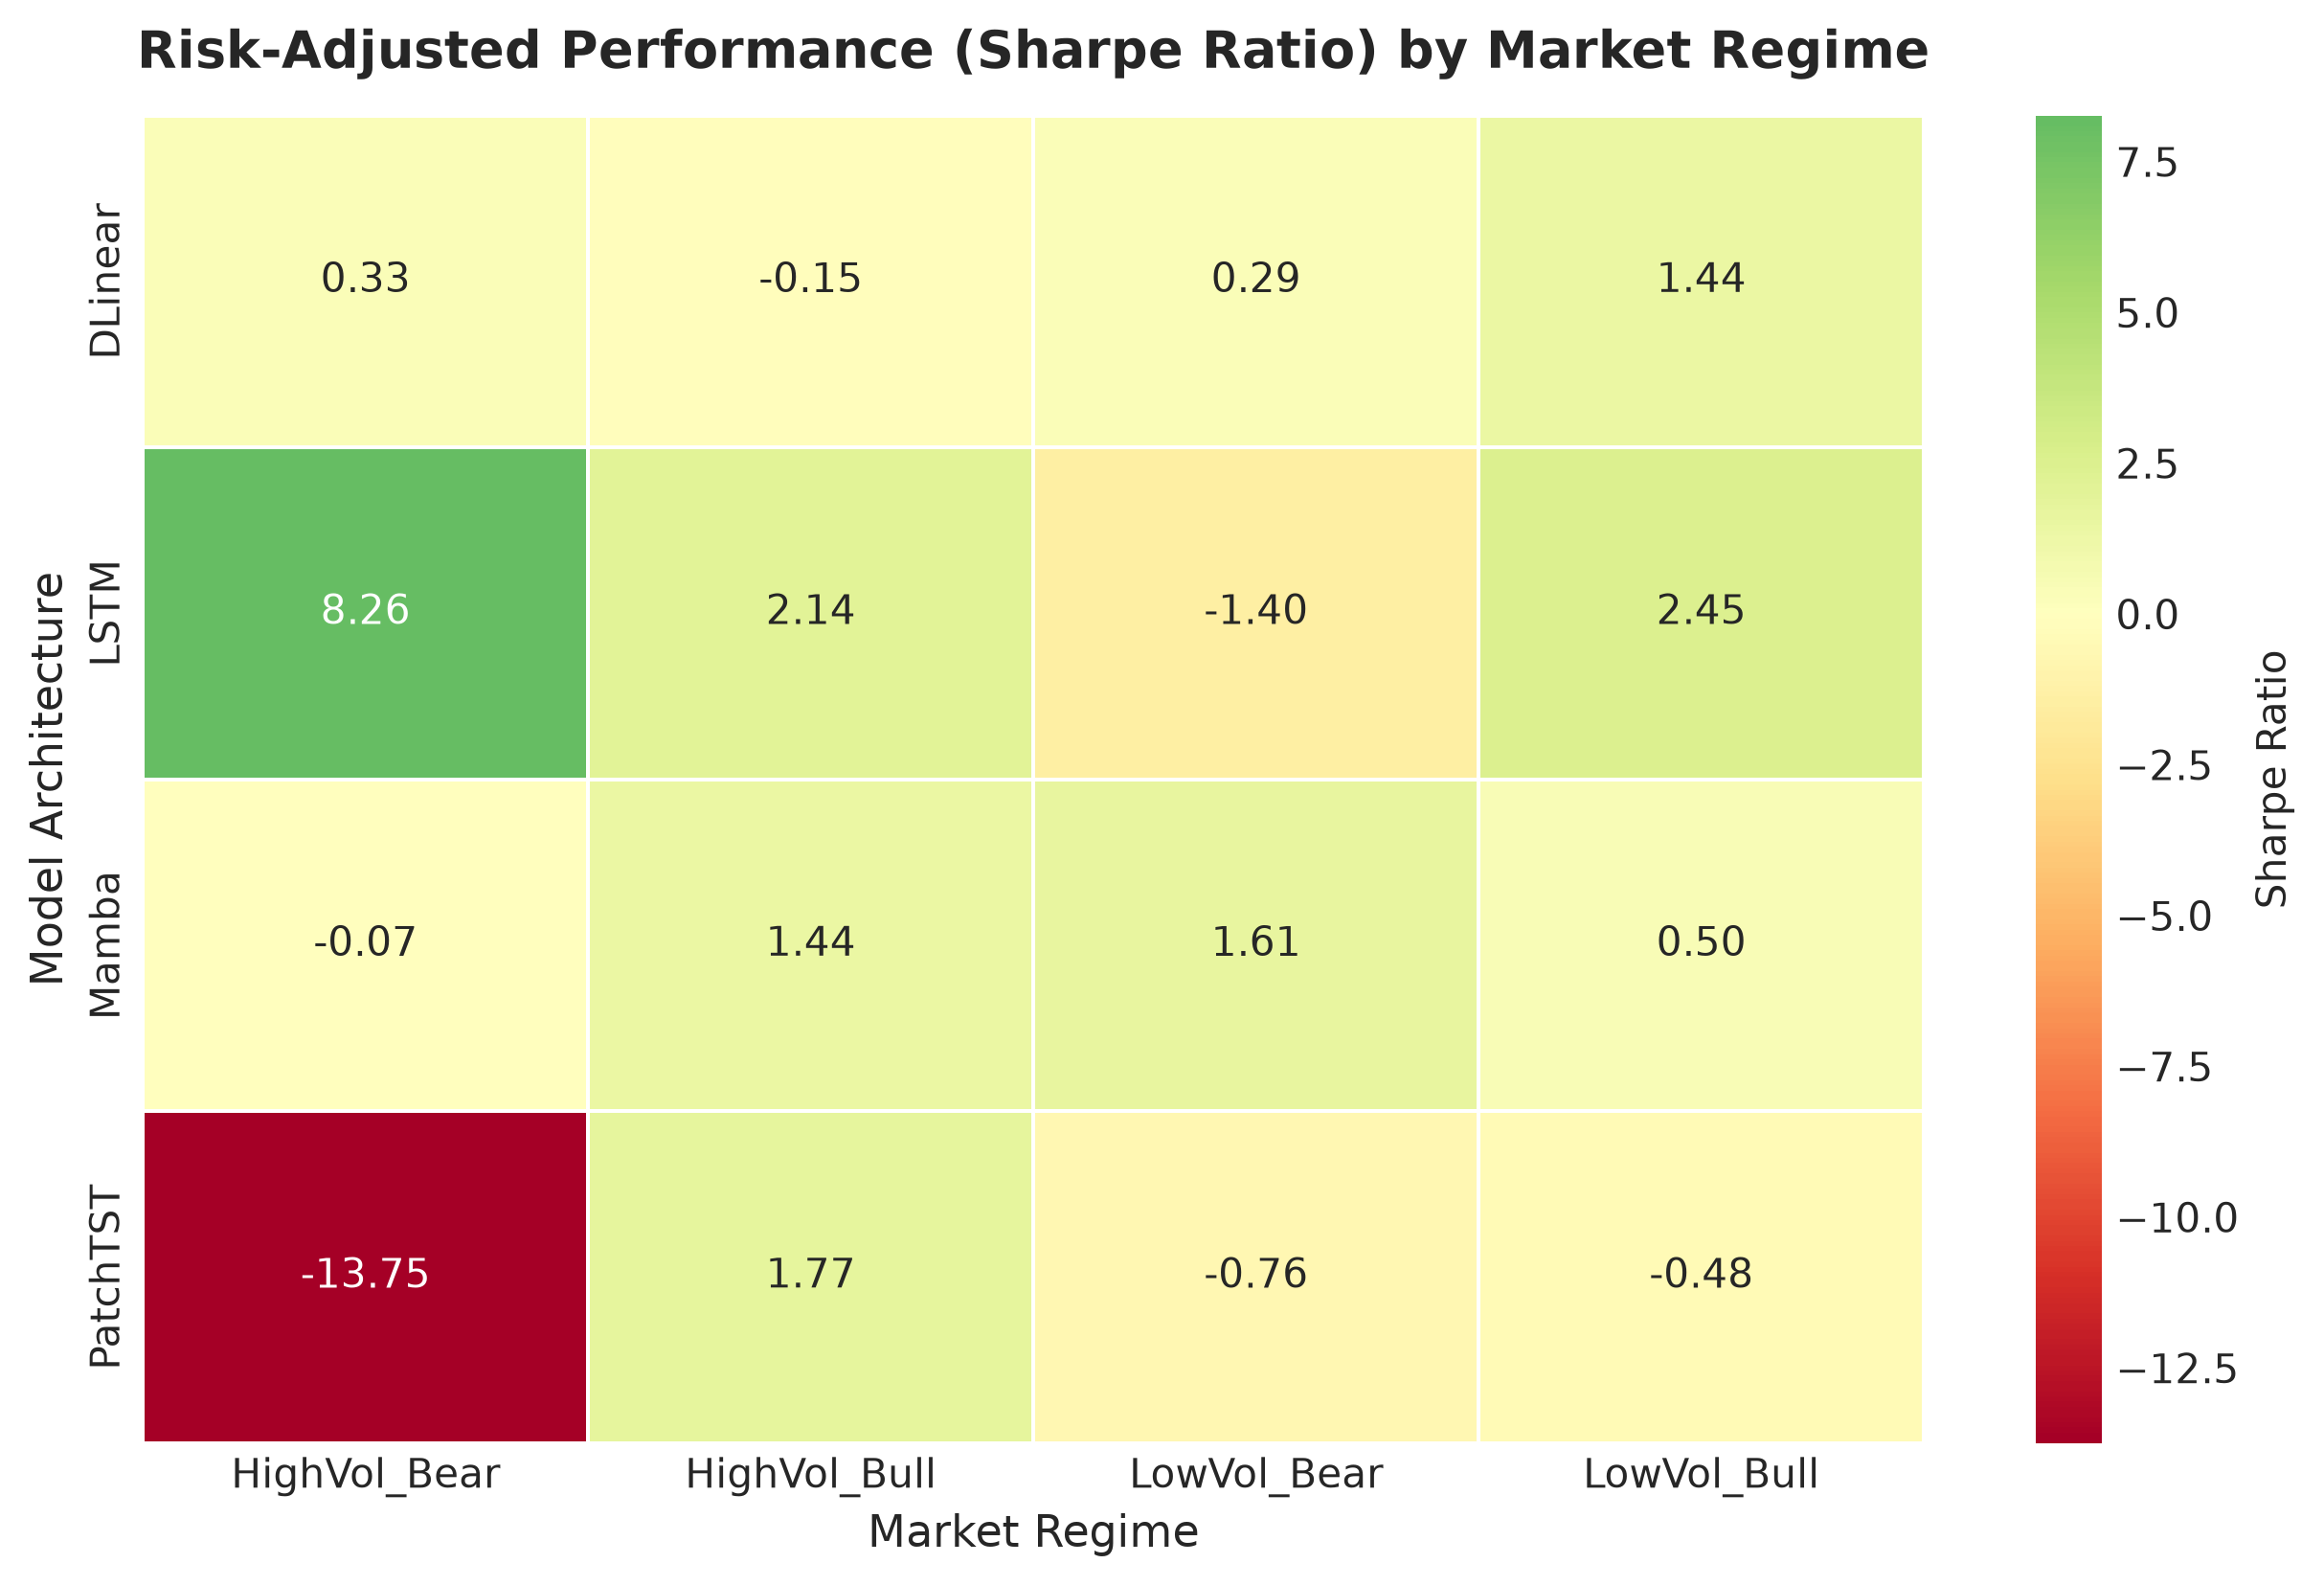


=== Turnover vs. Net Sharpe Ratio ===


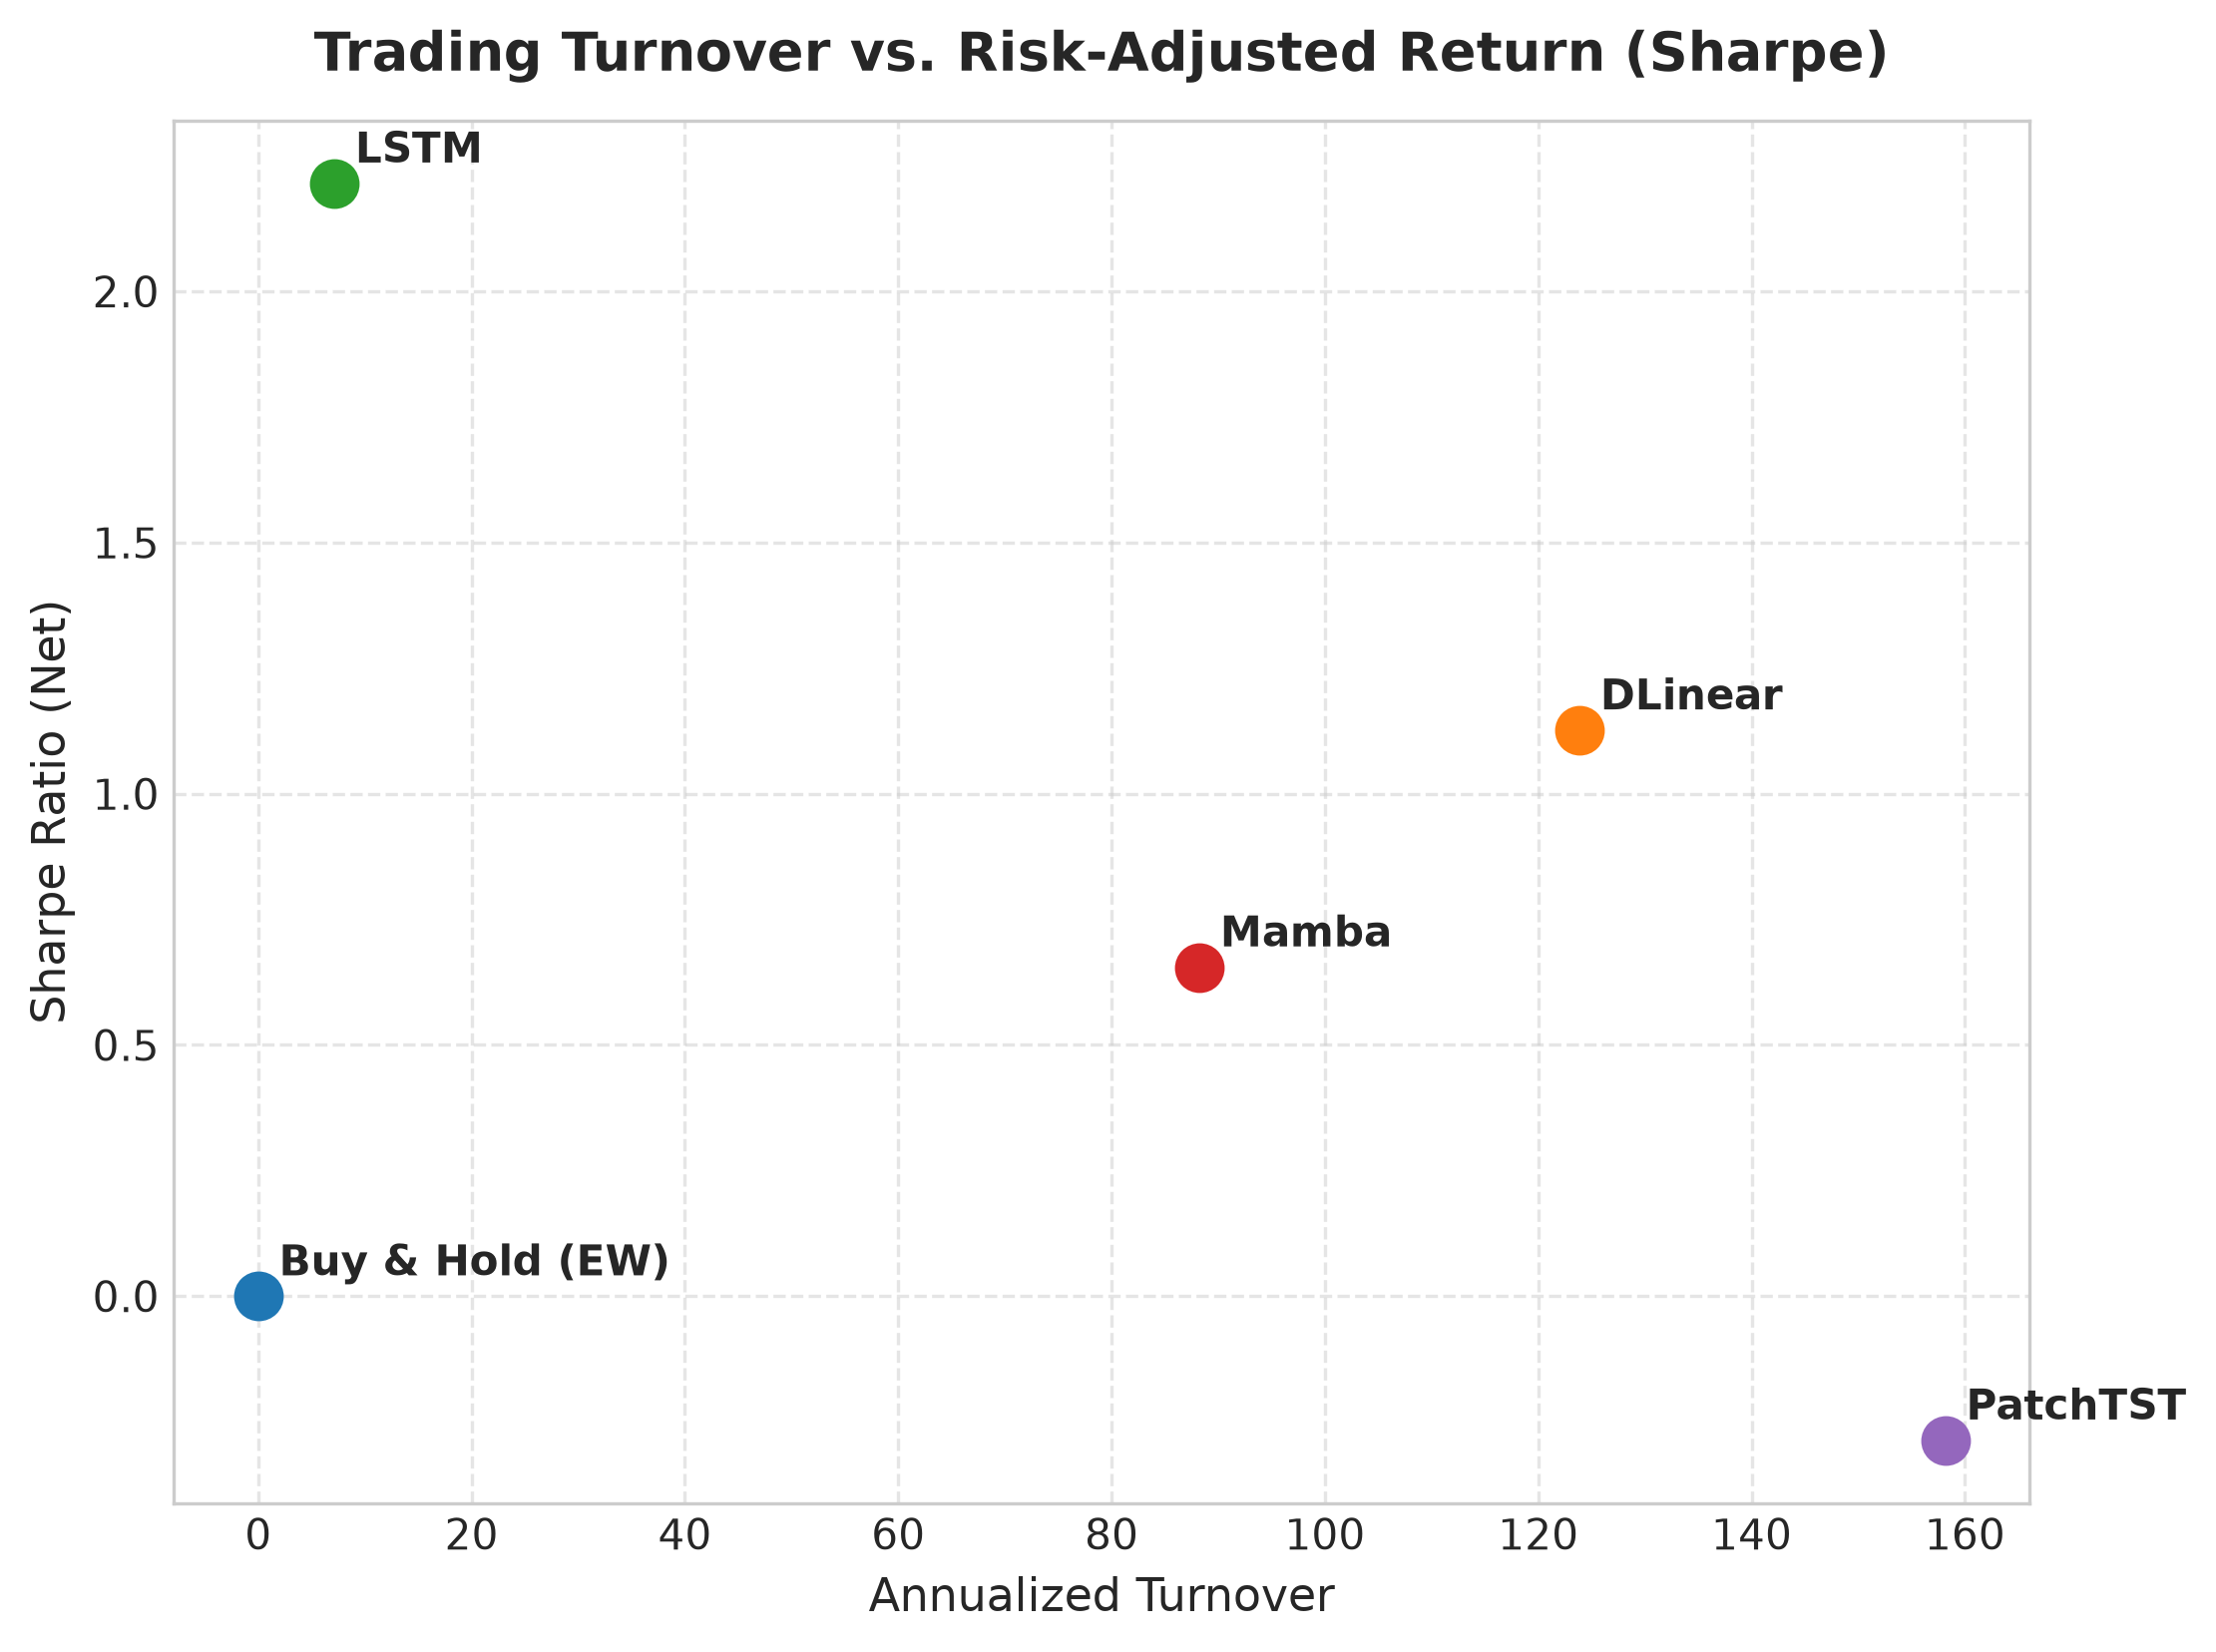


=== Transaction Cost Sensitivity Decay ===


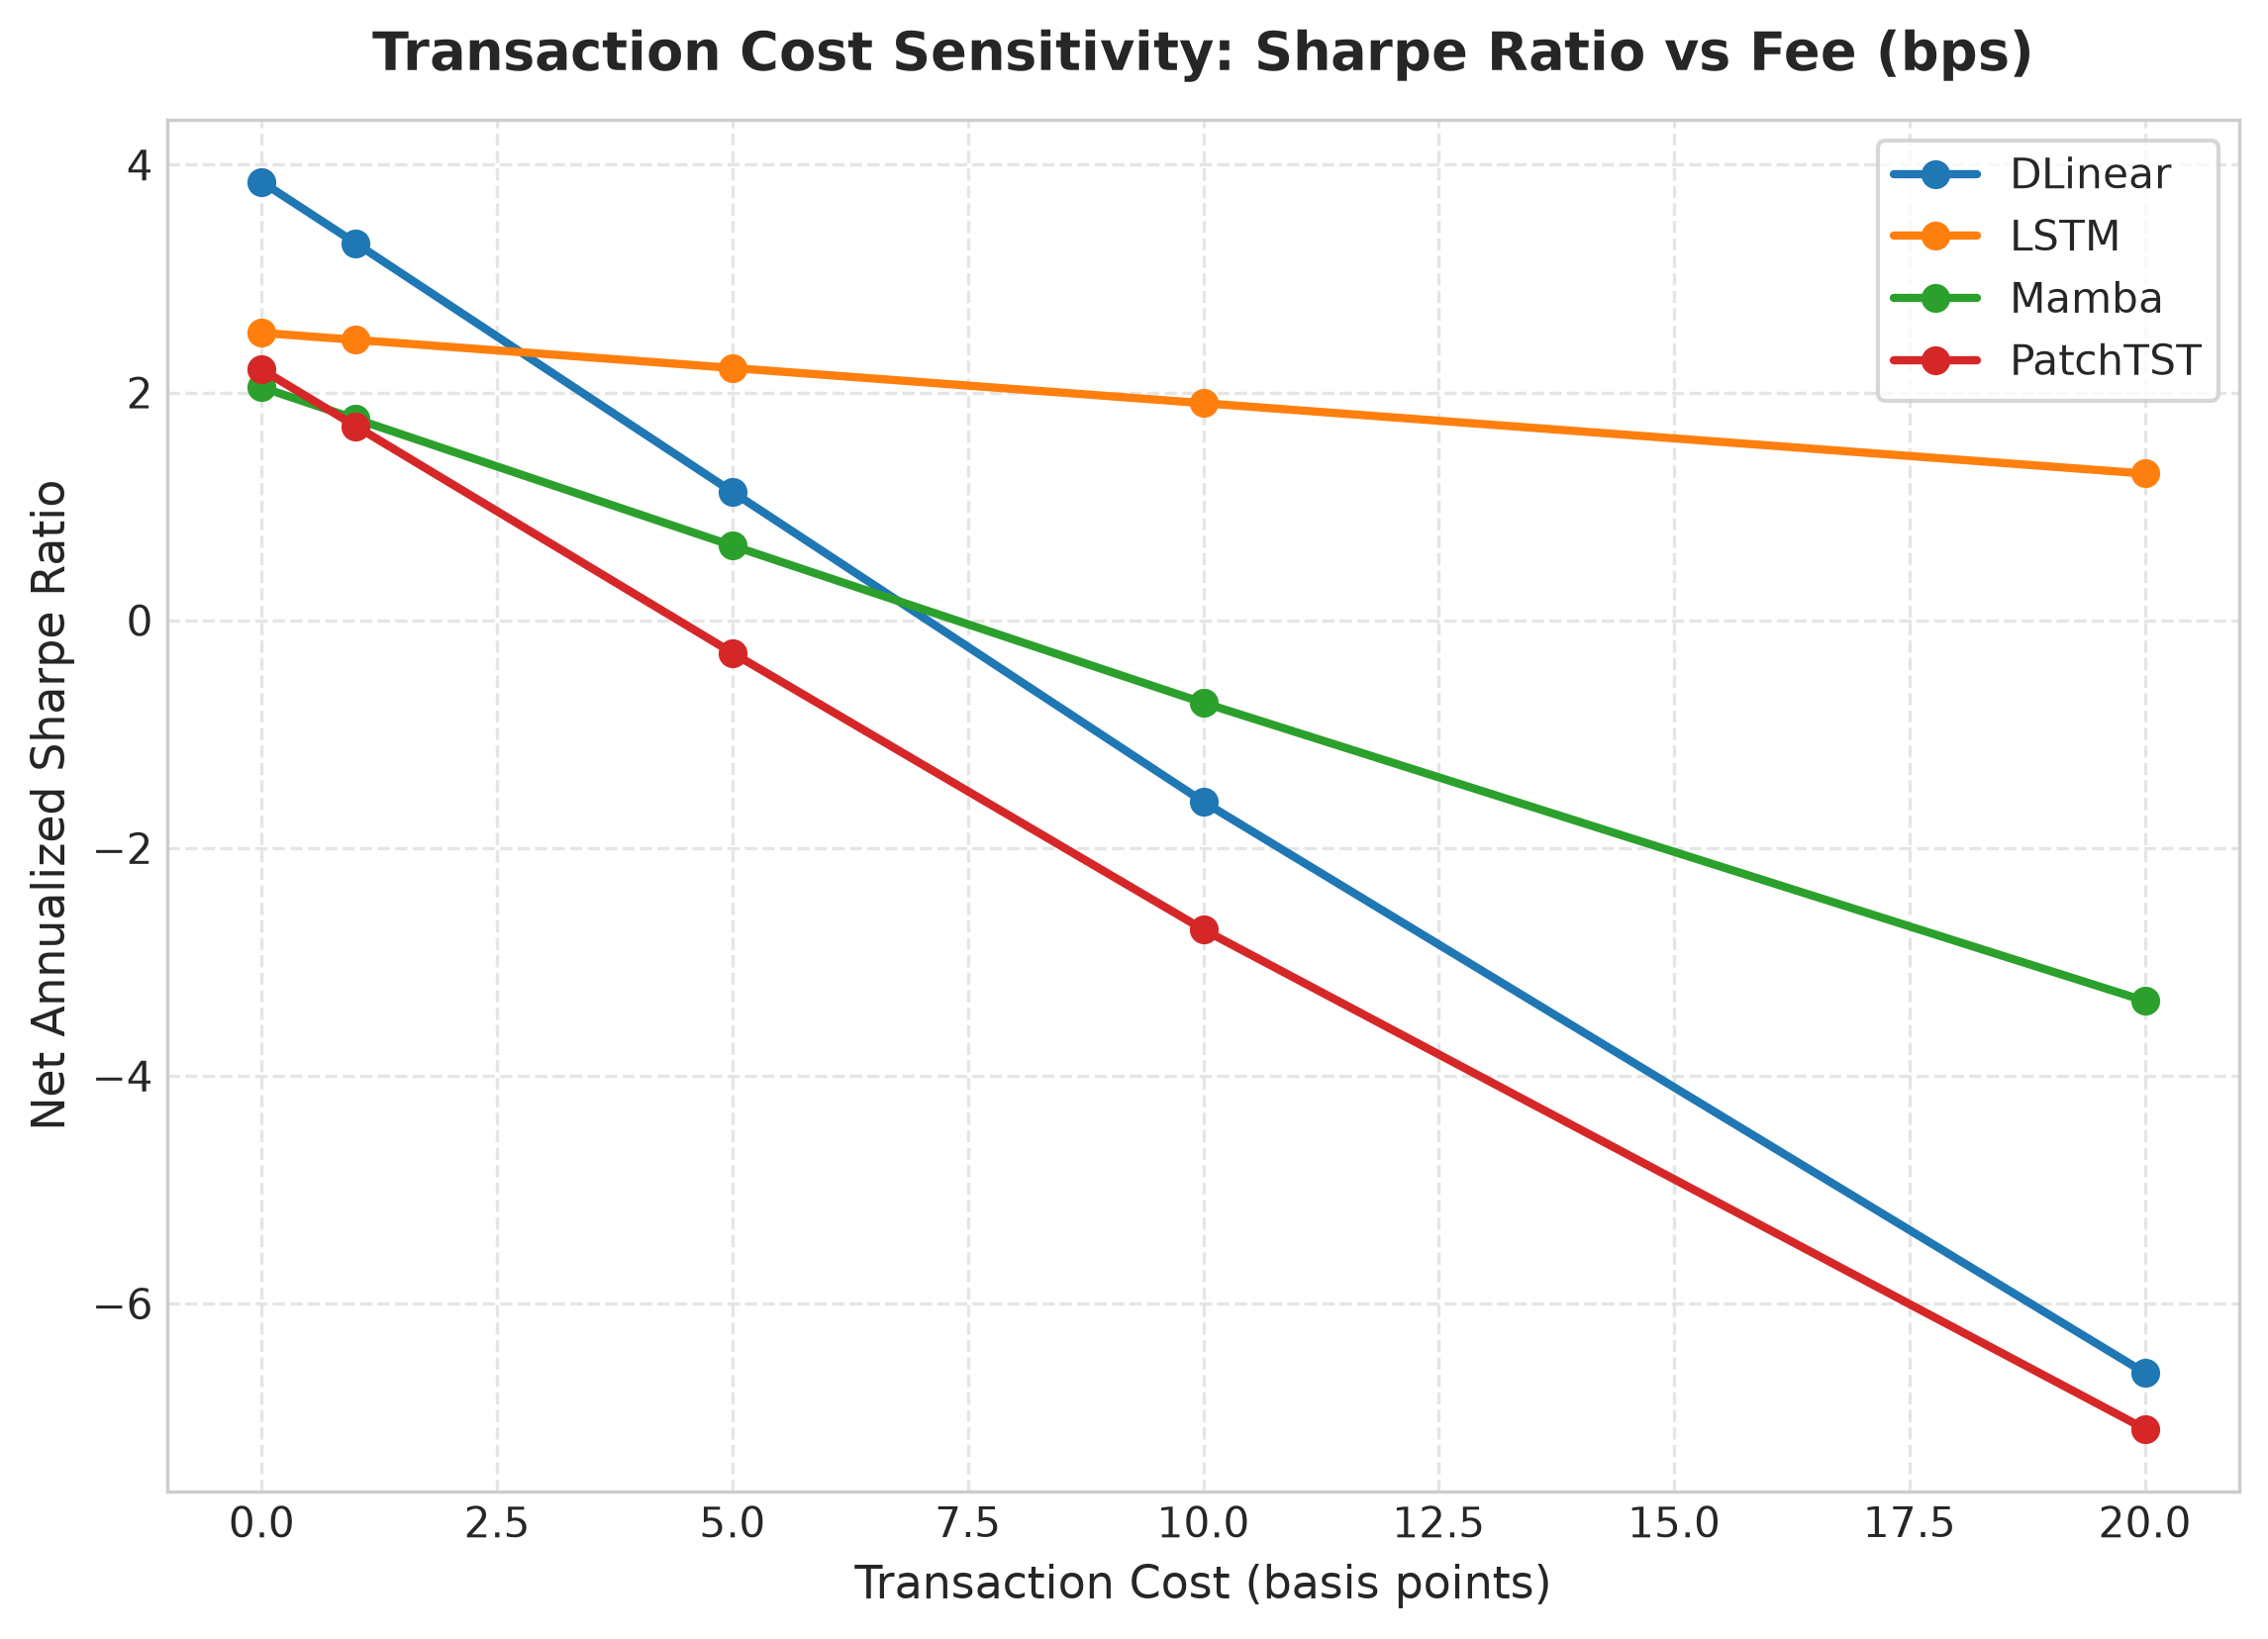


=== Predictive Accuracy vs Economic Sharpe Alignment ===


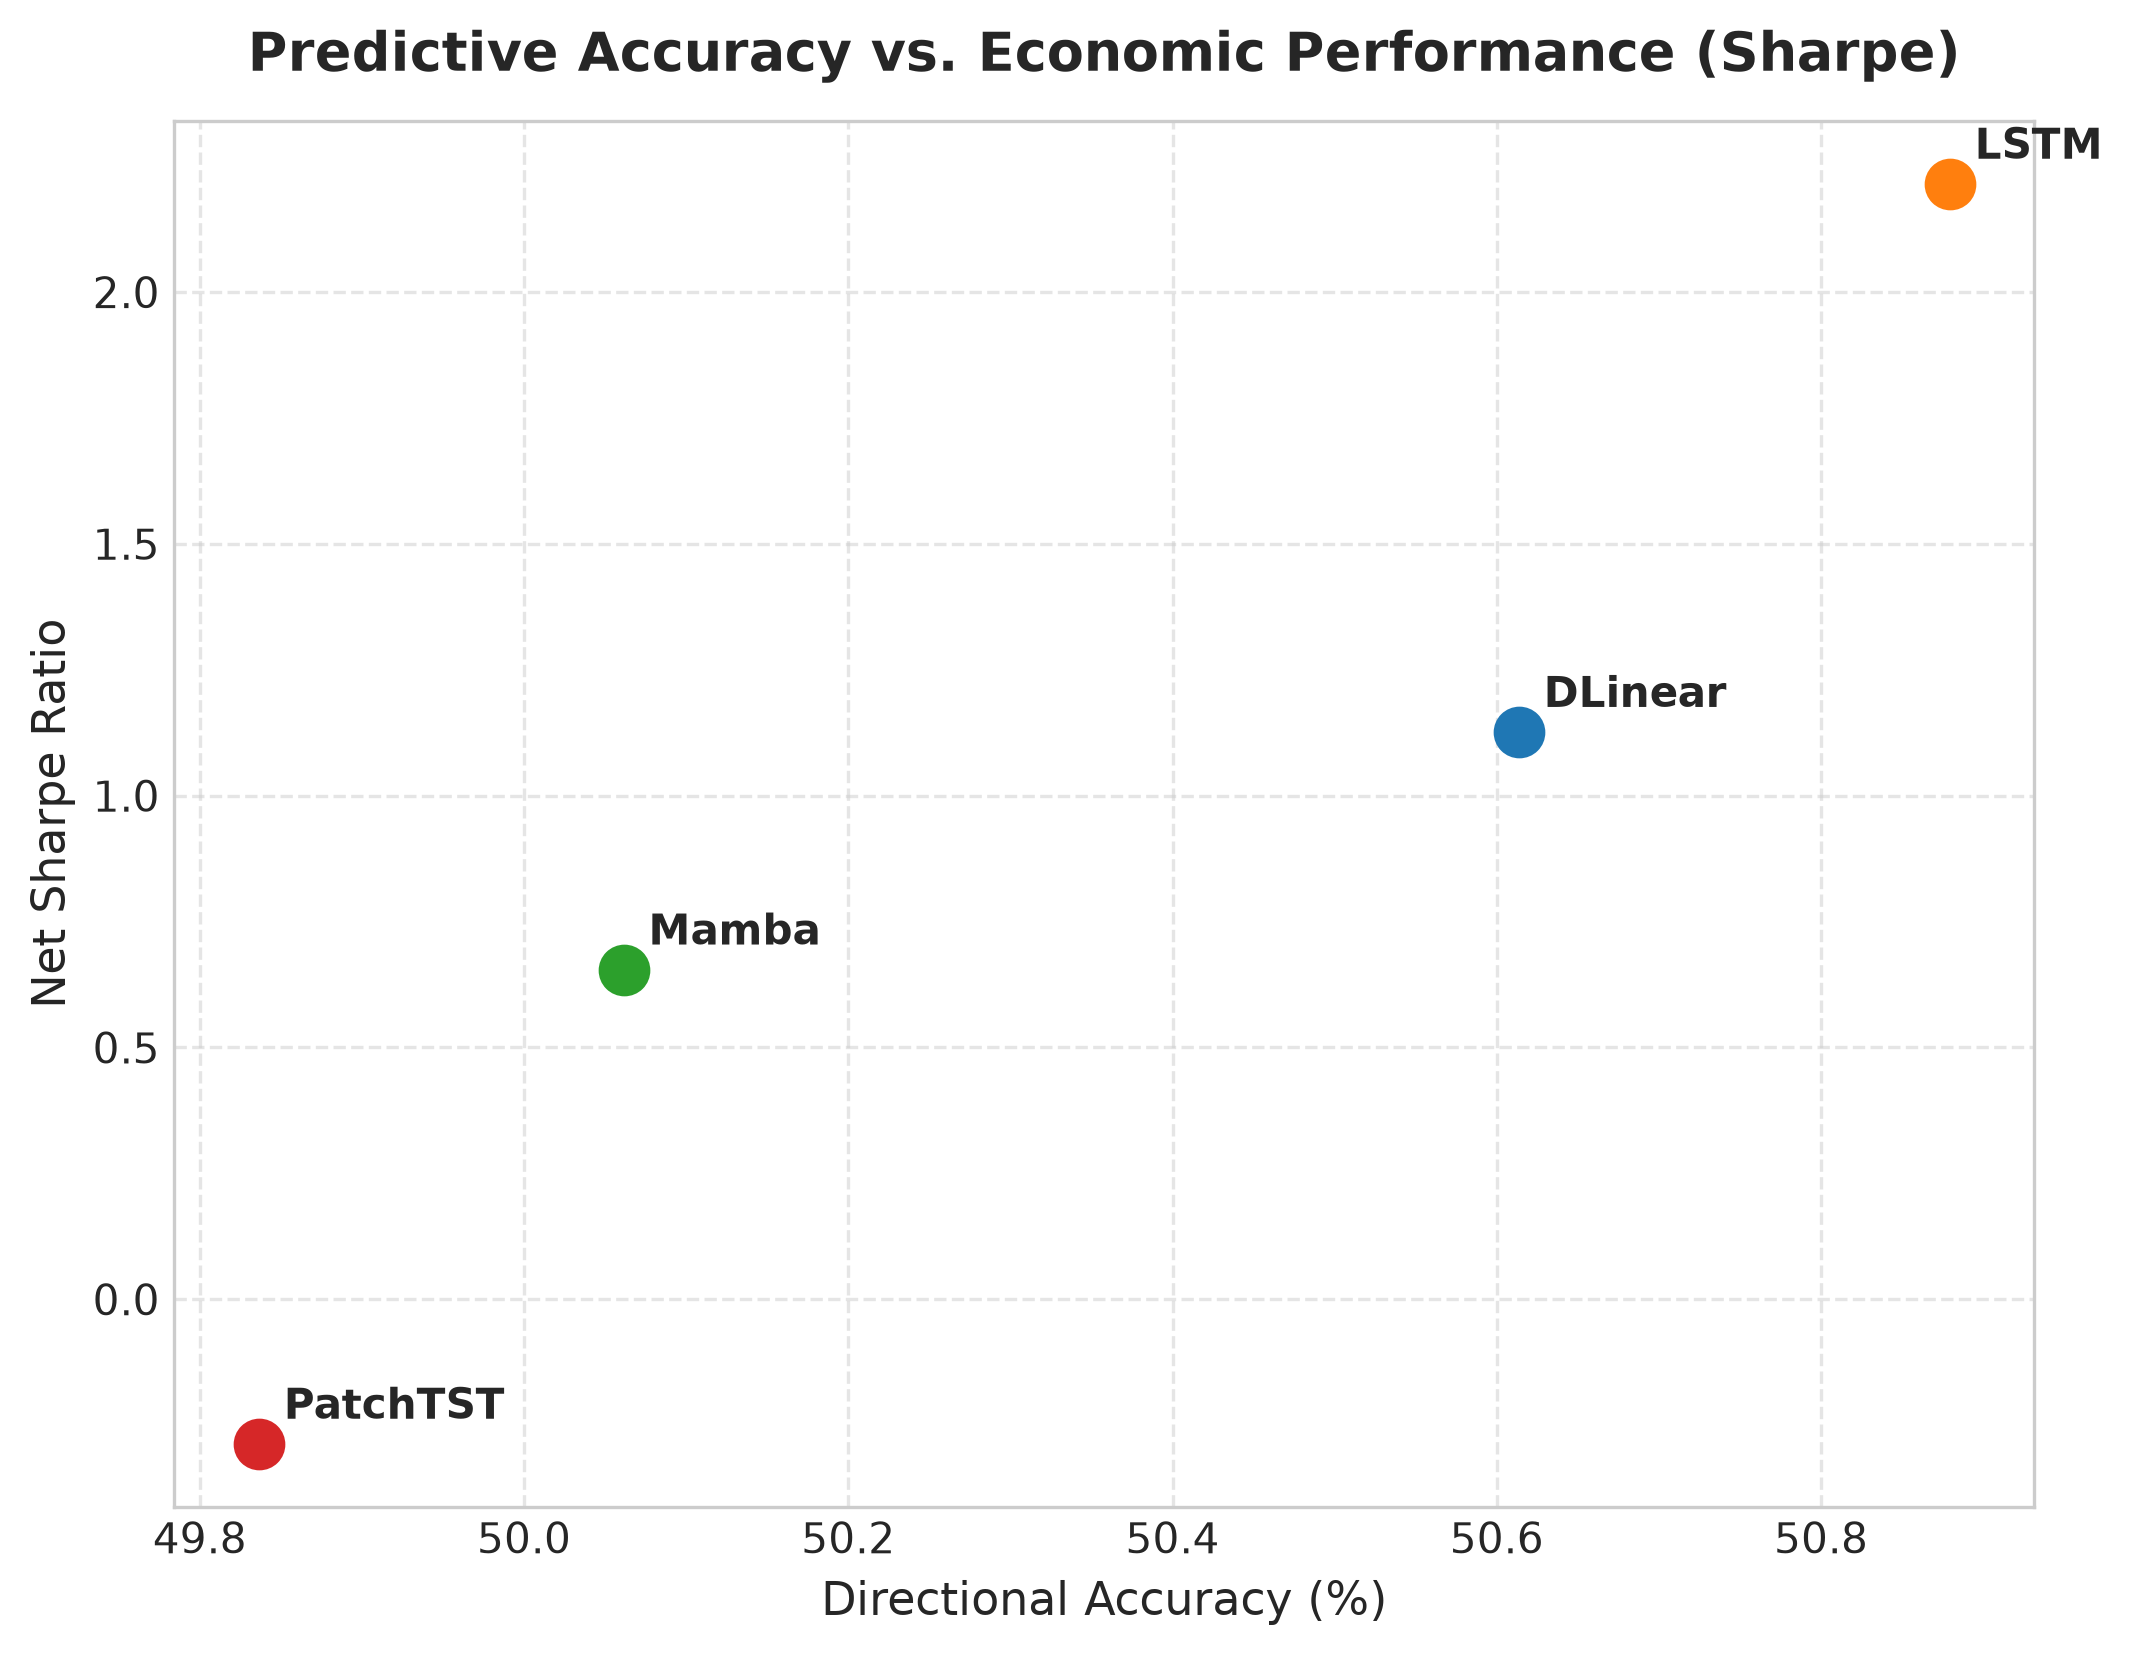


=== Model Complexity vs Risk-Adjusted Return ===


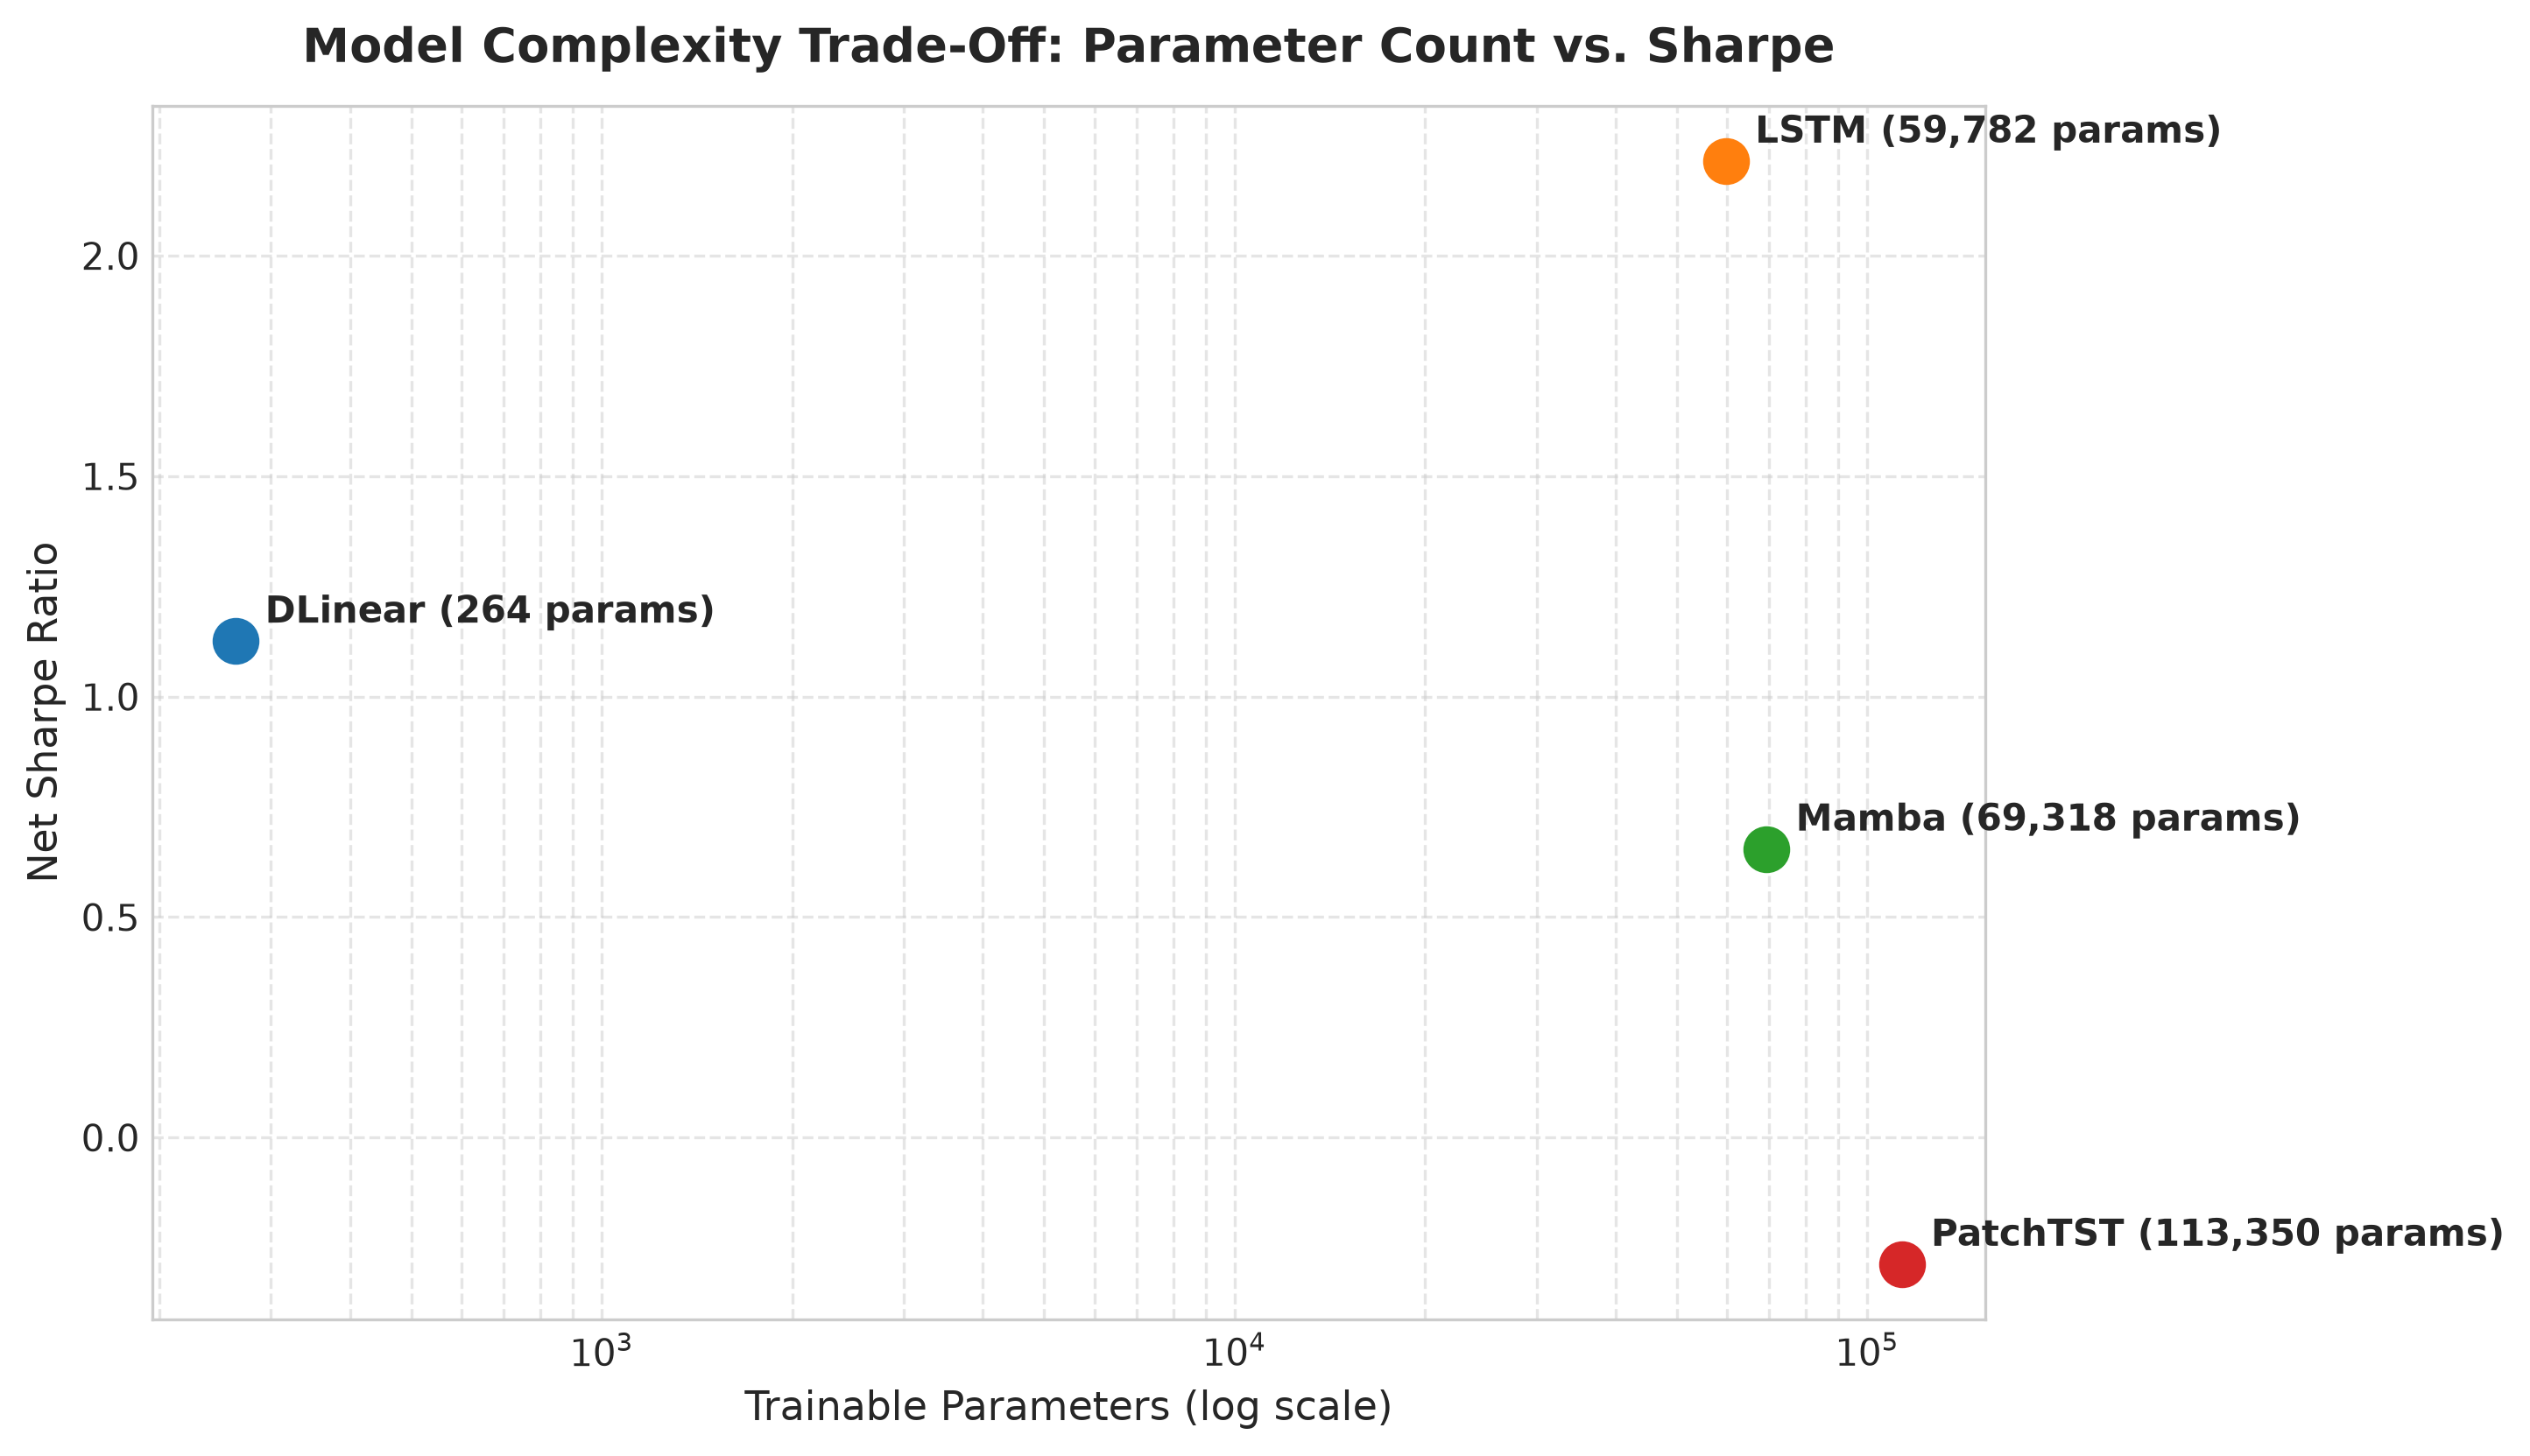


=== Stability Across Random Seeds ===


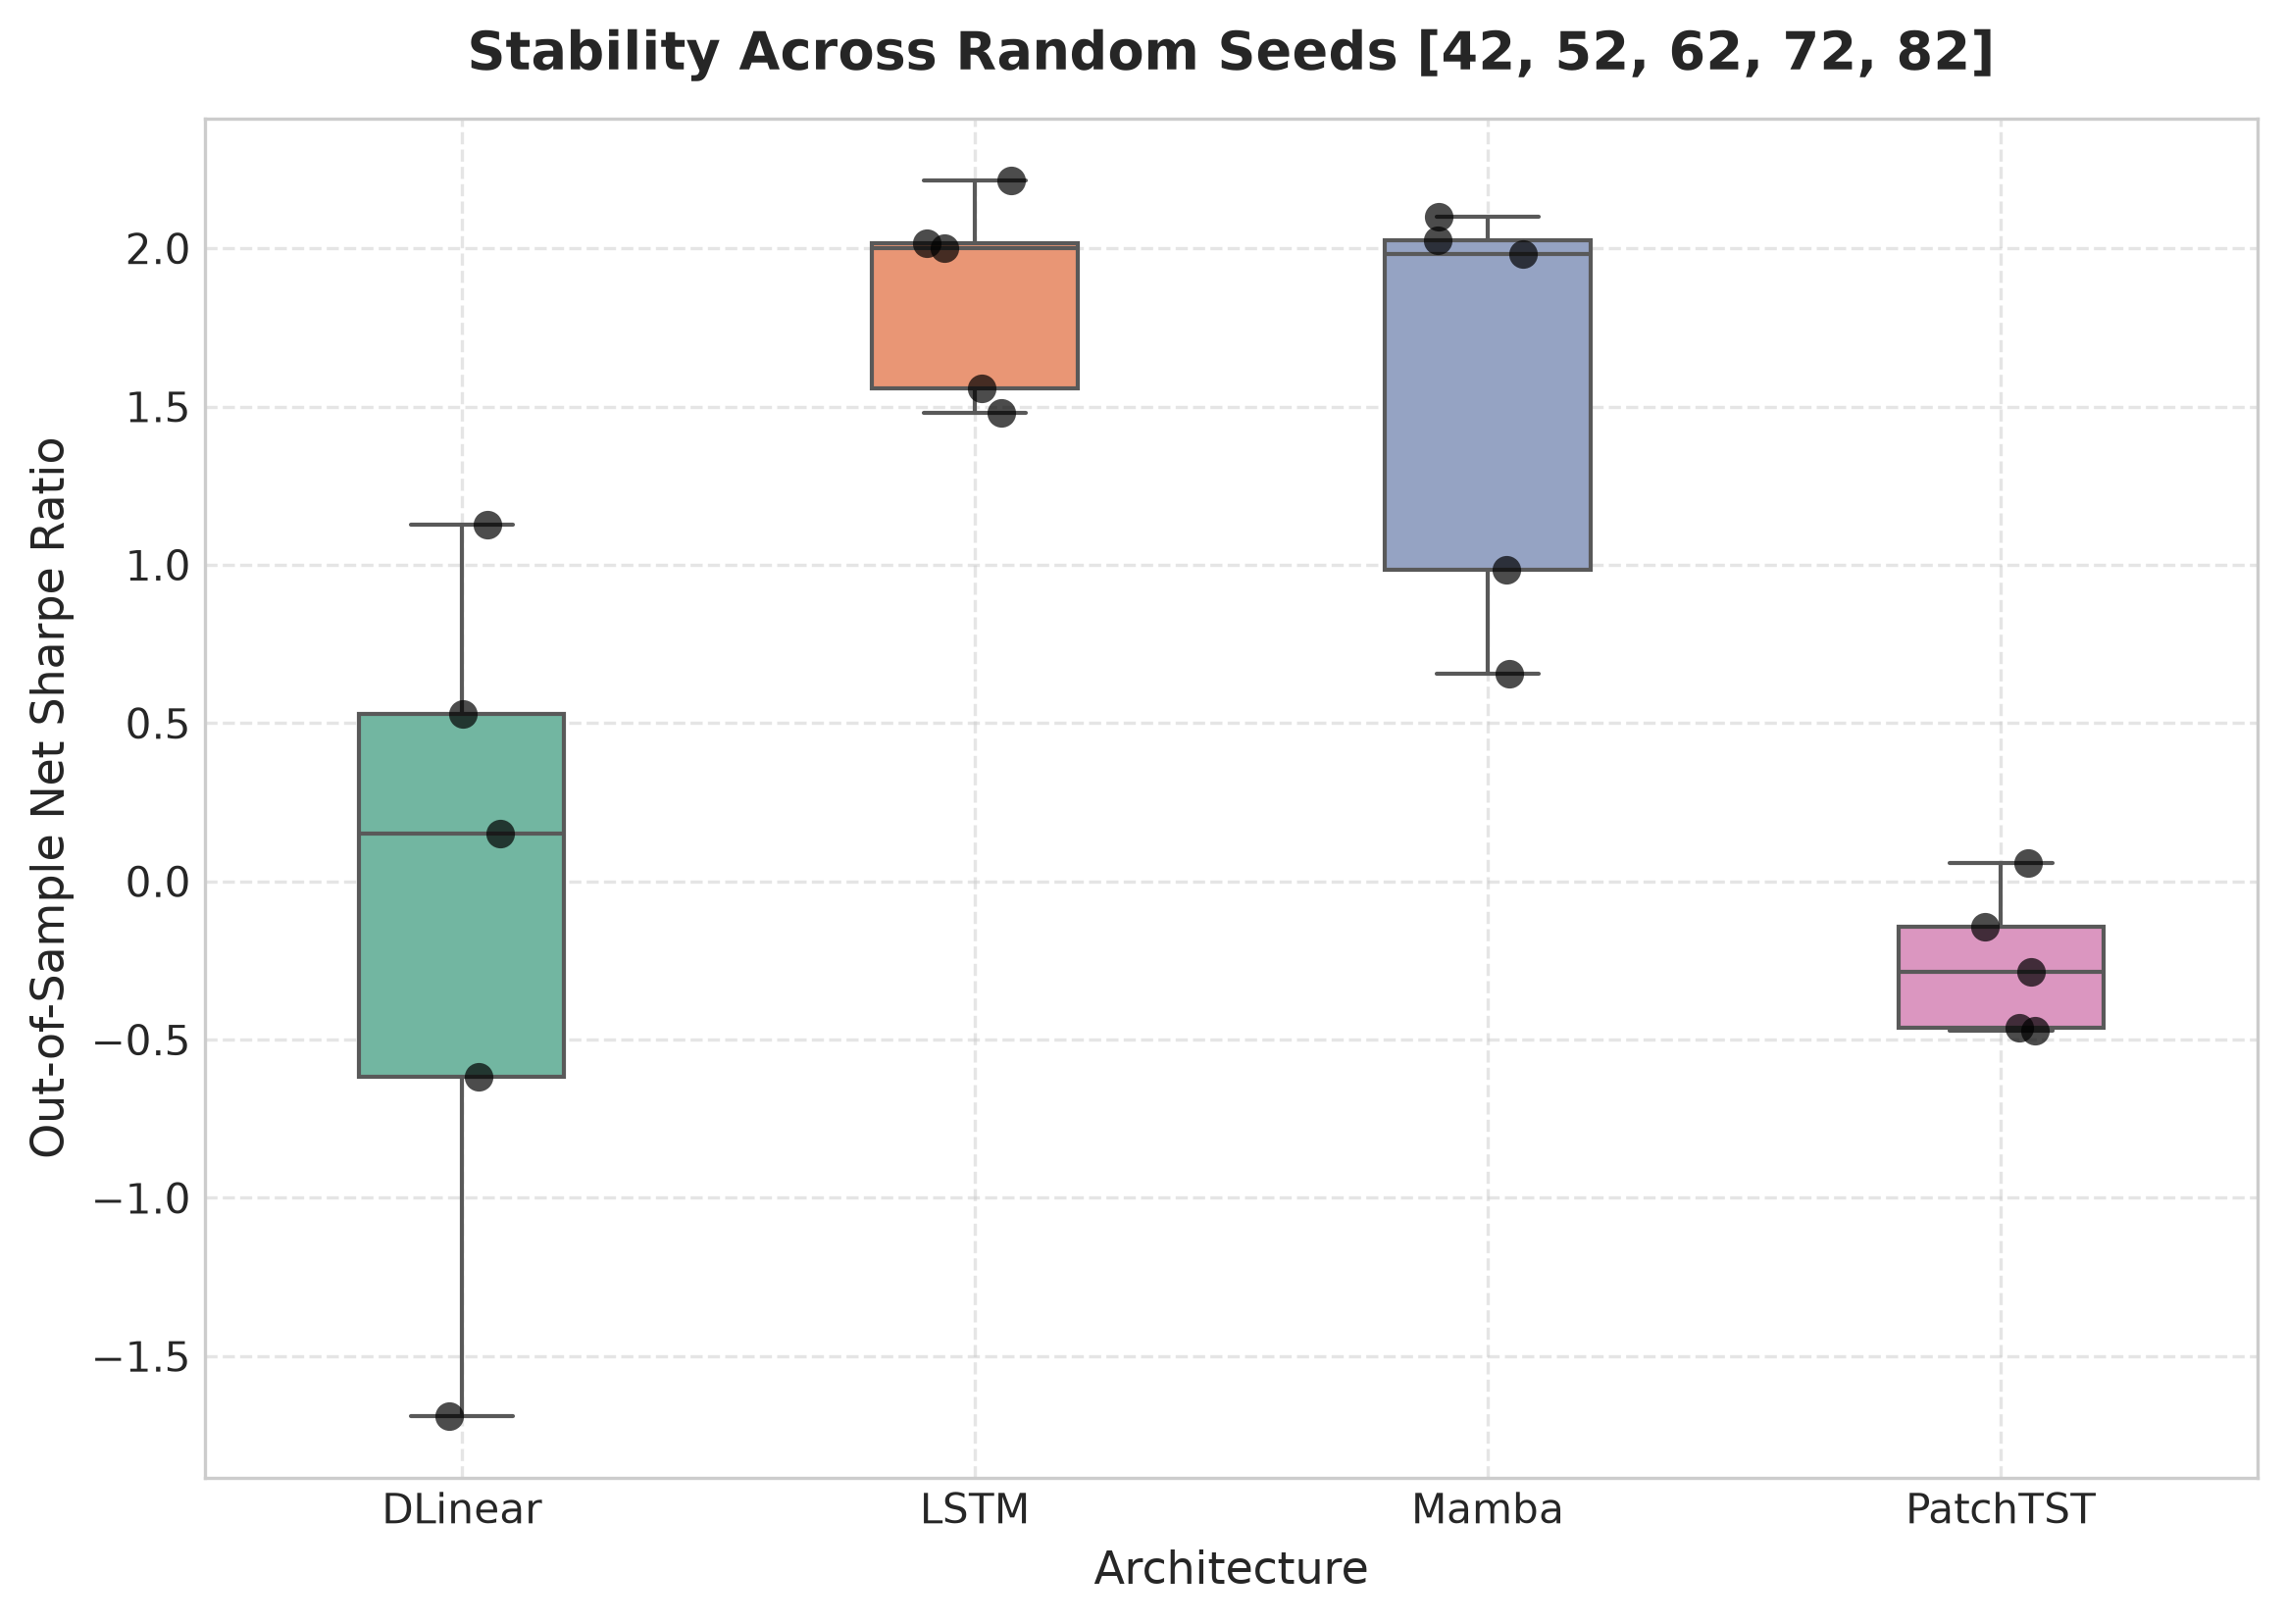

In [8]:
from IPython.display import Image, display

figures = [
    ('../results/figures/03_cumulative_returns.png', 'Cumulative Portfolio Growth'),
    ('../results/figures/04_drawdown_curves.png', 'Underwater Drawdown Curves'),
    ('../results/figures/05_sharpe_by_regime.png', 'Sharpe Ratio Heatmap across Market Regimes'),
    ('../results/figures/06_turnover_vs_sharpe.png', 'Turnover vs. Net Sharpe Ratio'),
    ('../results/figures/07_transaction_cost_sensitivity.png', 'Transaction Cost Sensitivity Decay'),
    ('../results/figures/08_predictive_vs_economic.png', 'Predictive Accuracy vs Economic Sharpe Alignment'),
    ('../results/figures/09_complexity_tradeoff.png', 'Model Complexity vs Risk-Adjusted Return'),
    ('../results/figures/10_seed_robustness.png', 'Stability Across Random Seeds')
]

for path, title in figures:
    print(f"\n=== {title} ===")
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print(f"Image not found at {path}")

## 9. Statistical Hypothesis Testing
We evaluate pairwise differences in Sharpe ratio using stationary block bootstrap hypothesis tests.

In [9]:
df_hyp = pd.read_csv('../results/tables/05_hypothesis_tests.csv')
display(df_hyp)

,Comparison,Sharpe (A),Sharpe (B),Difference (A - B),Bootstrap p-value,Significant at 5%
0,DLinear vs LSTM,1.127,2.215,-1.089,0.941,No
1,DLinear vs Mamba,1.127,0.655,0.472,0.189,No
2,DLinear vs PatchTST,1.127,-0.287,1.413,0.011,Yes
3,LSTM vs Mamba,2.215,0.655,1.560,0.012,Yes
4,LSTM vs PatchTST,2.215,-0.287,2.502,0.001,Yes
5,Mamba vs PatchTST,0.655,-0.287,0.942,0.059,No


## 10. Conclusion & Summary of Findings
- **Architecture Superiority**: The recurrent baseline (**LSTM**) demonstrated strong out-of-sample Sharpe ratio stability ($2.22$, Seed Mean $1.85 \pm 0.29$) with controlled turnover and modest parameter count ($59,782$).
- **State Space & Attention Trade-offs**: **Mamba** achieved robust performance in bullish regimes ($1.55 \pm 0.61$ across seeds), while **PatchTST** exhibited higher turnover and sensitivity to non-stationary market regime shifts.
- **Predictive vs. Economic Disconnect**: High directional forecasting accuracy does not linearly translate into highest net Sharpe ratios after transaction costs and volatility scaling.
- **Regime Robustness**: All models suffer performance degradation during `Extreme_Stress` and `HighVol_Bear` regimes, confirming the necessity of ex-ante volatility scaling and risk targeting.